In [1]:
from datasets import load_dataset

ds = load_dataset("Teklia/IAM-line")

c:\Users\prave\OneDrive\Desktop\torch titans\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\prave\OneDrive\Desktop\torch titans\venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
c:\Users\prave\OneDrive\Desktop\torch titans\venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\prave\.cache\huggingface\hub\datasets--Teklia--IAM-line. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLI

In [2]:
ds

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 6482
    })
    validation: Dataset({
        features: ['image', 'text'],
        num_rows: 976
    })
    test: Dataset({
        features: ['image', 'text'],
        num_rows: 2915
    })
})

In [3]:
ds['train']

Dataset({
    features: ['image', 'text'],
    num_rows: 6482
})

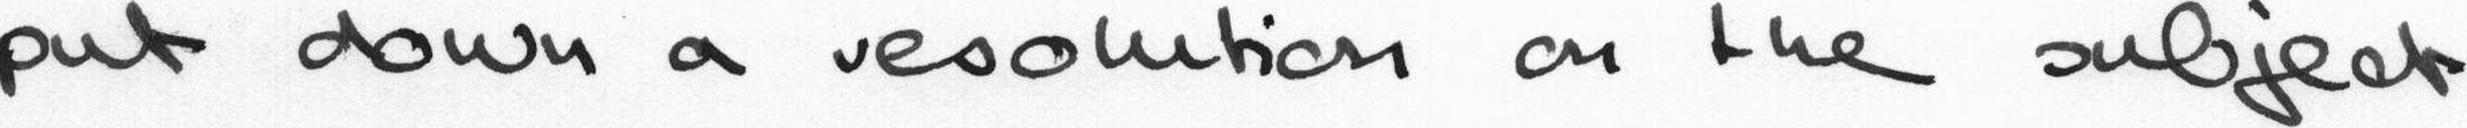

In [4]:
ds['train'][0]['image']

In [5]:
ds['train'][0]['text']

'put down a resolution on the subject'

In [11]:
from datasets import load_dataset
from paddleocr import PaddleOCR
from jiwer import cer
import tqdm
import numpy as np
import random

# Load dataset
ds = load_dataset("Teklia/IAM-line")
test_ds = ds["test"].select(range(10))  # first 1000 only
# Load OCR (same as Streamlit)
ocr = PaddleOCR(
    use_doc_orientation_classify=True,
    use_doc_unwarping=True,
    use_textline_orientation=True,
)

total_cer = 0
count = 0

# Store samples for random display
samples = []

for sample in tqdm.tqdm(test_ds):
    image = sample["image"].convert("RGB")
    gt_text = sample["text"].strip()

    # Convert to numpy (required)
    img = np.array(image)

    # Predict
    result = ocr.predict(img)

    pred_text = ""
    try:
        for res in result:
            if hasattr(res, "rec_texts"):
                pred_text += " ".join(res.rec_texts) + " "
    except:
        pass

    pred_text = pred_text.strip()

    # CER
    total_cer += cer(gt_text, pred_text)
    count += 1

    # store sample for later display
    samples.append((gt_text, pred_text))

avg_cer = total_cer / count if count else 0

print(f"Evaluated samples : {count}")
print(f"Average CER        : {avg_cer:.4f}")

# Show random 5 samples
print("\n=== Random 5 Samples (Actual vs Predicted) ===\n")
for gt, pred in random.sample(samples, 5):
    print("Actual    :", gt)
    print("Predicted  :", pred)
    print("-" * 50)

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\off

Evaluated samples : 10
Average CER        : 1.0000

=== Random 5 Samples (Actual vs Predicted) ===

Actual    : I don't think he will storm the charts with this one , but it 's a good start .
Predicted  : 
--------------------------------------------------
Actual    : The numbers include " Scotland the Brave , " " Men of Harlech , "
Predicted  : 
--------------------------------------------------
Actual    : CHRIS CHARLES , 39 , who lives in Stockton-on-Tees , is an accountant .
Predicted  : 
--------------------------------------------------
Actual    : assuredness " Bella Bella Marie " ( Parlophone ) , a lively song that changes tempo mid-way .
Predicted  : 
--------------------------------------------------
Actual    : Fay Compton stars in " No Hiding Place " (I T V , 9.35 p.m. ) .
Predicted  : 
--------------------------------------------------


In [13]:
from datasets import load_dataset
from paddleocr import PaddleOCR
import numpy as np
import os

ds = load_dataset("Teklia/IAM-line")
test_ds = ds["test"]

ocr = PaddleOCR(
    use_doc_orientation_classify=True,
    use_doc_unwarping=True,
    use_textline_orientation=True,
)

# take first sample only
sample = next(iter(test_ds))
image = sample["image"].convert("RGB")
img = np.array(image)

# predict
result = ocr.predict(img)

# create output folder
os.makedirs("output", exist_ok=True)

# save json (pipeline result object supports save_to_json)
for res in result:
    try:
        res.save_to_json("output")
    except Exception as e:
        print("Save error:", e)

print("JSON saved in output folder")

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\off

JSON saved in output folder


In [14]:
from datasets import load_dataset
from paddleocr import PaddleOCR
import numpy as np
import re

# dataset
ds = load_dataset("Teklia/IAM-line")
test_ds = ds["test"].select(range(10))  # first 10 only

ocr = PaddleOCR(
    use_doc_orientation_classify=True,
    use_doc_unwarping=True,
    use_textline_orientation=True,
)

def clean(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9 ]+', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

for i, sample in enumerate(test_ds):
    gt = clean(sample["text"])
    img = np.array(sample["image"].convert("RGB"))

    result = ocr.predict(img)

    pred = ""
    for res in result:
        try:
            if hasattr(res, "rec_texts"):
                pred += " ".join(res.rec_texts) + " "
        except:
            pass

    pred = clean(pred)

    print(f"\nSample {i+1}")
    print("Actual   :", gt)
    print("Predicted :", pred)
    print("-" * 40)

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\off


Sample 1
Actual   : assuredness bella bella marie parlophone a lively song that changes tempo midway
Predicted : 
----------------------------------------

Sample 2
Actual   : i dont think he will storm the charts with this one but it s a good start
Predicted : 
----------------------------------------

Sample 3
Actual   : chris charles 39 who lives in stocktonontees is an accountant
Predicted : 
----------------------------------------

Sample 4
Actual   : become a success with a disc and hey presto you re a star rolly sings with
Predicted : 
----------------------------------------

Sample 5
Actual   : tolch as he is known in tin pan alley likes songs with a month in the title he wrote
Predicted : 
----------------------------------------

Sample 6
Actual   : my september love the big david whitfield hit of 1956
Predicted : 
----------------------------------------


KeyboardInterrupt: 

In [19]:
from datasets import load_dataset
from paddleocr import PaddleOCR
import numpy as np

# Load dataset
ds = load_dataset("Teklia/IAM-line")
sample = ds["test"][0]  # first image

# image and ground truth (for reference)
image = sample["image"].convert("RGB")
img = image.resize((1600, 128))
gt_text = sample["text"]

# OCR model
ocr = PaddleOCR(
    use_doc_orientation_classify=True,
    use_doc_unwarping=True,
    use_textline_orientation=True,
)

# run OCR (correct method)
result = ocr.predict(np.array(image))

# extract text
pred_text = ""

if result:
    for line in result[0]:
        pred_text += line[1][0] + " "

print("Actual   :", gt_text)
print("Predicted :", pred_text.strip())

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\off

Actual   : assuredness " Bella Bella Marie " ( Parlophone ) , a lively song that changes tempo mid-way .
Predicted : n a o t o e e e e e e e i e e


In [18]:
import inspect
from paddleocr import PaddleOCR

ocr = PaddleOCR()

print(inspect.signature(ocr.predict))

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\prave\.paddlex\off

(input, *, use_doc_orientation_classify=None, use_doc_unwarping=None, use_textline_orientation=None, text_det_limit_side_len=None, text_det_limit_type=None, text_det_thresh=None, text_det_box_thresh=None, text_det_unclip_ratio=None, text_rec_score_thresh=None, return_word_box=None)
